# **Import libraries**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import category_encoders as ce

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler,QuantileTransformer,PolynomialFeatures
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.model_selection import RandomizedSearchCV,train_test_split, cross_val_score
from sklearn.metrics import mean_squared_error,make_scorer
from lightgbm import LGBMRegressor


# **Data loading**

In [2]:
df_train = pd.read_csv('/kaggle/input/engage-2-value-from-clicks-to-conversions/train_data.csv')
print("shape train data :", df_train.shape)
df_test = pd.read_csv('/kaggle/input/engage-2-value-from-clicks-to-conversions/test_data.csv')
print("shape test data :", df_test.shape)

shape train data : (116023, 52)
shape test data : (29006, 51)


# **EDA**

In [3]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)


In [4]:
pd.set_option("display.max_columns",None)
pd.set_option("display.max_rows",None)

In [5]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 116023 entries, 0 to 116022
Data columns (total 52 columns):
 #   Column                                        Non-Null Count   Dtype  
---  ------                                        --------------   -----  
 0   trafficSource.isTrueDirect                    42890 non-null   object 
 1   purchaseValue                                 116023 non-null  float64
 2   browser                                       116023 non-null  object 
 3   device.screenResolution                       116023 non-null  object 
 4   trafficSource.adContent                       2963 non-null    object 
 5   trafficSource.keyword                         44162 non-null   object 
 6   screenSize                                    116023 non-null  object 
 7   geoCluster                                    116023 non-null  object 
 8   trafficSource.adwordsClickInfo.slot           4281 non-null    object 
 9   device.mobileDeviceBranding                   11

In [6]:
df_train.isnull().sum()

trafficSource.isTrueDirect                       73133
purchaseValue                                        0
browser                                              0
device.screenResolution                              0
trafficSource.adContent                         113060
trafficSource.keyword                            71861
screenSize                                           0
geoCluster                                           0
trafficSource.adwordsClickInfo.slot             111742
device.mobileDeviceBranding                          0
device.mobileInputSelector                           0
userId                                               0
trafficSource.campaign                               0
device.mobileDeviceMarketingName                     0
geoNetwork.networkDomain                             0
gclIdPresent                                         0
device.operatingSystemVersion                        0
sessionNumber                                        0
device.fla

****Target variable distribution****

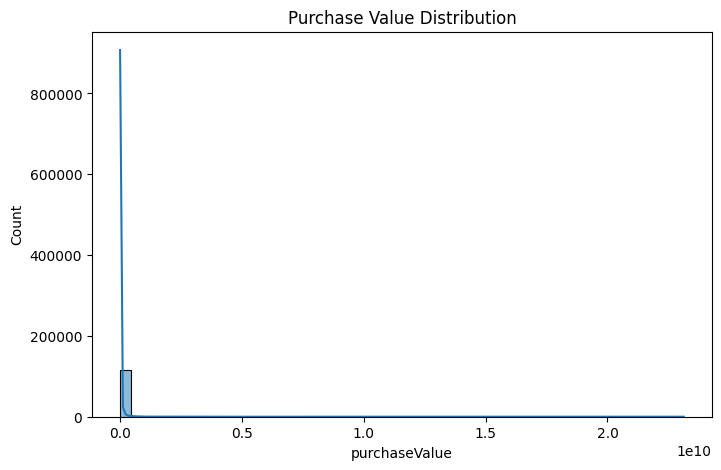

In [7]:

plt.figure(figsize=(8,5))
sns.histplot(df_train['purchaseValue'], bins=50, kde=True)
plt.title("Purchase Value Distribution")
plt.show()

In [8]:
missing_train = df_train.isnull().sum().sort_values(ascending=False)
print("Missing values in train data:\n", missing_train[missing_train > 0])

Missing values in train data:
 trafficSource.adContent                         113060
trafficSource.adwordsClickInfo.slot             111742
trafficSource.adwordsClickInfo.adNetworkType    111742
trafficSource.adwordsClickInfo.isVideoAd        111742
trafficSource.adwordsClickInfo.page             111742
trafficSource.referralPath                       73309
trafficSource.isTrueDirect                       73133
trafficSource.keyword                            71861
totals.bounces                                   68875
new_visits                                       35505
pageViews                                            8
dtype: int64


****Correlation heatmap for numerical features****

/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1


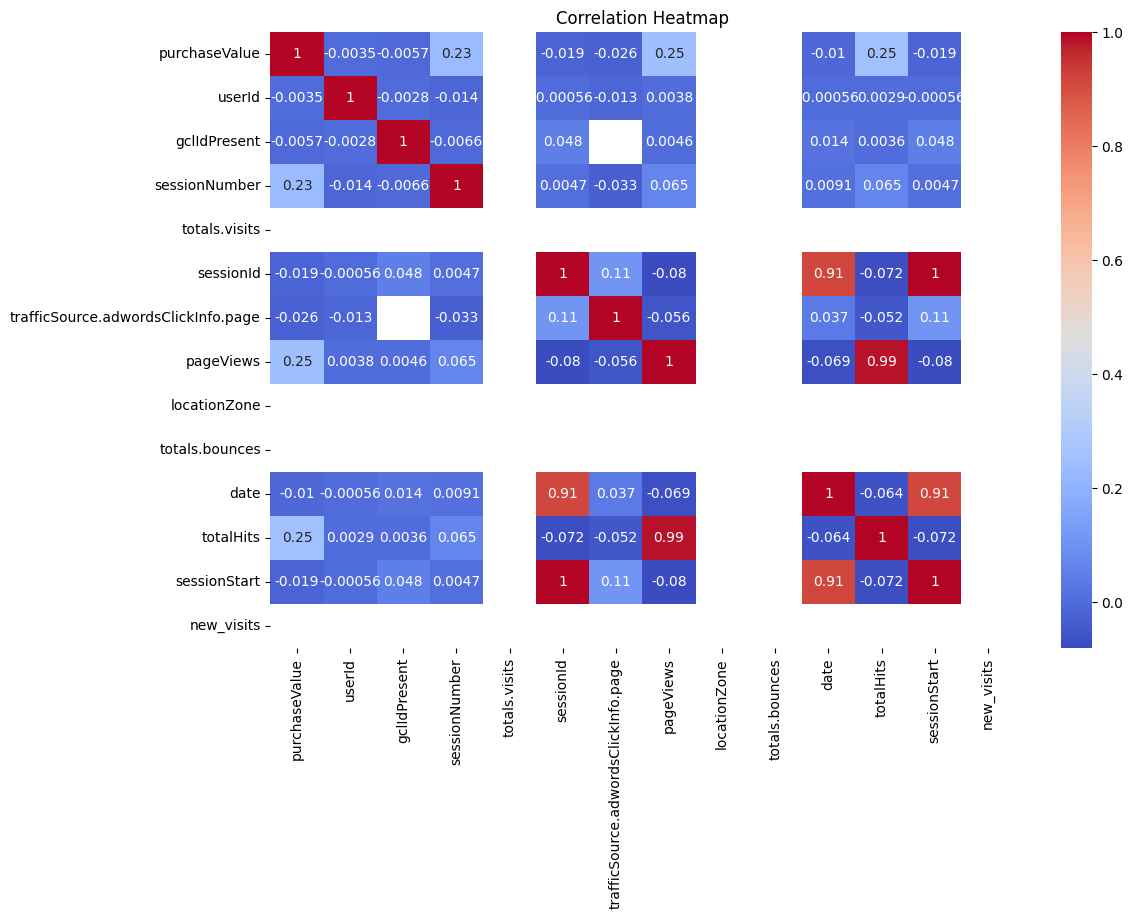

In [9]:
numeric_cols = df_train.select_dtypes(include=np.number).columns.tolist()
plt.figure(figsize=(12,8))
sns.heatmap(df_train[numeric_cols].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

****PurchaseValue vs totalHits****

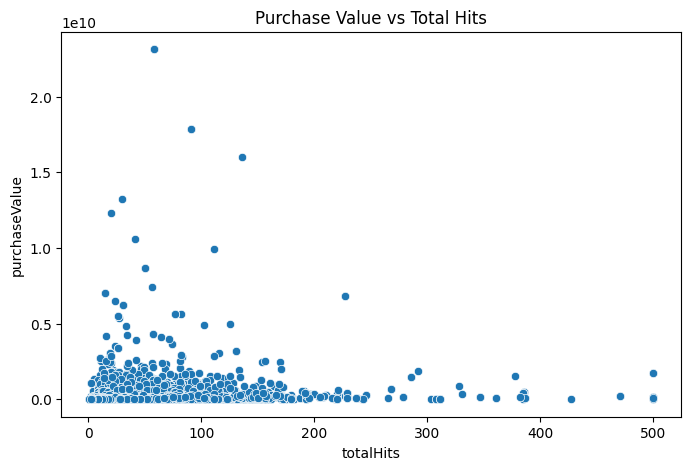

In [10]:

plt.figure(figsize=(8,5))
sns.scatterplot(x='totalHits', y='purchaseValue', data=df_train)
plt.title("Purchase Value vs Total Hits")
plt.show()

In [11]:
trafficSource_adContent_mod1 = df_train['trafficSource.adContent'].mode()[0]
df_train['trafficSource.adContent'] = df_train['trafficSource.adContent'].fillna(trafficSource_adContent_mod1)

trafficSource_adContent_mod = df_test['trafficSource.adContent'].mode()[0]
df_test['trafficSource.adContent'] = df_test['trafficSource.adContent'].fillna(trafficSource_adContent_mod)

In [12]:
df_train['trafficSource.isTrueDirect'].value_counts()

trafficSource.isTrueDirect
True    42890
Name: count, dtype: int64

In [13]:
df_train['trafficSource.isTrueDirect'] = df_train['trafficSource.isTrueDirect'].fillna(False).astype(bool)
df_test['trafficSource.isTrueDirect'] = df_test['trafficSource.isTrueDirect'].fillna(False).astype(bool)

In [14]:
df_train['trafficSource.isTrueDirect'] = df_train['trafficSource.isTrueDirect'].astype(int)
df_test['trafficSource.isTrueDirect'] = df_test['trafficSource.isTrueDirect'].astype(int)

In [15]:
trafficSource_adwordsClickInfo_slot_mod = df_train['trafficSource.adwordsClickInfo.slot'].mode()[0]
df_train['trafficSource.adwordsClickInfo.slot'] = df_train['trafficSource.adwordsClickInfo.slot'].fillna(trafficSource_adwordsClickInfo_slot_mod)

trafficSource_adwordsClickInfo_slot_mod1 = df_test['trafficSource.adwordsClickInfo.slot'].mode()[0]
df_test['trafficSource.adwordsClickInfo.slot'] = df_test['trafficSource.adwordsClickInfo.slot'].fillna(trafficSource_adwordsClickInfo_slot_mod1)

In [16]:
trafficSource_keyword_mod1 = df_train['trafficSource.keyword'].mode()[0]
df_train['trafficSource.keyword'] = df_train['trafficSource.keyword'].fillna(trafficSource_keyword_mod1)

trafficSource_keyword_mod = df_test['trafficSource.keyword'].mode()[0]
df_test['trafficSource.keyword'] = df_test['trafficSource.keyword'].fillna(trafficSource_keyword_mod)

In [17]:
df_train['trafficSource.adwordsClickInfo.adNetworkType'] = df_train['trafficSource.adwordsClickInfo.adNetworkType'].fillna('Na')

df_test['trafficSource.adwordsClickInfo.adNetworkType'] = df_test['trafficSource.adwordsClickInfo.adNetworkType'].fillna('Na')

In [18]:
df_train['trafficSource.adwordsClickInfo.isVideoAd'] = df_train['trafficSource.adwordsClickInfo.isVideoAd'].fillna(True).astype(bool)

df_test['trafficSource.adwordsClickInfo.isVideoAd'] = df_test['trafficSource.adwordsClickInfo.isVideoAd'].fillna(True).astype(bool)

In [19]:
df_train['trafficSource.adwordsClickInfo.isVideoAd'] = df_train['trafficSource.adwordsClickInfo.isVideoAd'].astype(int)

df_test['trafficSource.adwordsClickInfo.isVideoAd'] = df_test['trafficSource.adwordsClickInfo.isVideoAd'].astype(int)

In [20]:
trafficSource_adwordsClickInfo_page_mod1 = df_train['trafficSource.adwordsClickInfo.page'].mode()[0]
df_train['trafficSource.adwordsClickInfo.page'] = df_train['trafficSource.adwordsClickInfo.page'].fillna(trafficSource_adwordsClickInfo_page_mod1)

trafficSource_adwordsClickInfo_page_mod = df_test['trafficSource.adwordsClickInfo.page'].mode()[0]
df_test['trafficSource.adwordsClickInfo.page'] = df_test['trafficSource.adwordsClickInfo.page'].fillna(trafficSource_adwordsClickInfo_page_mod)

In [21]:
df_train['trafficSource.referralPath'] = df_train['trafficSource.referralPath'].fillna('Na')

df_test['trafficSource.referralPath'] = df_test['trafficSource.referralPath'].fillna('Na')

In [22]:
pageViews_mod = df_train['pageViews'].median()
df_train['pageViews'] = df_train['pageViews'].fillna(pageViews_mod)

pageViews_mod = df_test['pageViews'].median()
df_test['pageViews'] = df_test['pageViews'].fillna(pageViews_mod)

In [23]:
df_train['totals.bounces'].value_counts()

totals.bounces
1.0    47148
Name: count, dtype: int64

In [24]:
df_train['totals.bounces'] = df_train['totals.bounces'].fillna(0)
df_test['totals.bounces'] = df_test['totals.bounces'].fillna(0)

In [25]:
df_train["device.isMobile"] = df_train["device.isMobile"].astype(int)
df_test["device.isMobile"] = df_test["device.isMobile"].astype(int)

In [26]:
df_train['new_visits'] = df_train['new_visits'].fillna(0)
df_test['new_visits'] = df_test['new_visits'].fillna(0)

In [27]:
cols_to_drop = ['trafficSource.adContent', 'trafficSource.adwordsClickInfo.slot',
                'trafficSource.adwordsClickInfo.isVideoAd', 'trafficSource.adwordsClickInfo.adNetworkType',
                'trafficSource.adwordsClickInfo.page']


if 'purchaseValue' in df_train.columns:
    y_train = df_train['purchaseValue']
    x_train = df_train.drop(columns=['purchaseValue'] + cols_to_drop)
else:
    raise ValueError("The target column 'purchaseValue' is missing in the training dataset.")


In [28]:
x_test = df_test.drop(columns=cols_to_drop)

****Handle missing values for numerical columns****

In [29]:
numerical_cols = x_train.select_dtypes(include=['float64', 'int64']).columns
for col in numerical_cols:
    median_value = x_train[col].median()
    x_train[col].fillna(median_value, inplace=True)
    if col in x_test.columns: 
        x_test[col].fillna(median_value, inplace=True)


**Handle missing values for categorical columns**

In [30]:
categorical_cols = x_train.select_dtypes(include='object').columns
for col in categorical_cols:
    mode_value = x_train[col].mode()[0]
    x_train[col].fillna(mode_value, inplace=True)
    if col in x_test.columns:  
        x_test[col].fillna(mode_value, inplace=True)

In [31]:
qt = QuantileTransformer(output_distribution='normal', random_state=42)
x_train[numerical_cols] = qt.fit_transform(x_train[numerical_cols])
x_test[numerical_cols] = qt.transform(x_test[numerical_cols])


In [32]:
numerical_pipe = Pipeline([
    ('scaler', StandardScaler()), 
    ('poly', PolynomialFeatures(degree=2, include_bias=False)) 
])

target_encoder = ce.TargetEncoder(cols=categorical_cols)

df_train[categorical_cols] = target_encoder.fit_transform(df_train[categorical_cols], y_train)
df_test[categorical_cols] = target_encoder.transform(df_test[categorical_cols])

In [33]:
preprocessor = ColumnTransformer([
    ('num', numerical_pipe, numerical_cols),
])

transformed_x_train_num = preprocessor.fit_transform(df_train)
transformed_x_test_num = preprocessor.transform(df_test)

transformed_x_train = np.hstack((transformed_x_train_num, df_train[categorical_cols].values))
transformed_x_test = np.hstack((transformed_x_test_num, df_test[categorical_cols].values))

print("Final shapes:", transformed_x_train.shape, transformed_x_test.shape)


Final shapes: (116023, 151) (29006, 151)


# XGBOOST MODEL

In [34]:
def rmse_score(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

rmse_scorer = make_scorer(rmse_score, greater_is_better=False)
results = {}

In [35]:
param_grid = {
    'max_depth': [4, 6, 8, 10],
    'learning_rate': [0.01, 0.05, 0.1],
    'n_estimators': [500, 1000, 1500],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'gamma': [0, 0.1, 0.2],
    'reg_alpha': [0, 0.1, 1],
    'reg_lambda': [1, 1.5, 2],
}

xgb_model = XGBRegressor(
    tree_method='gpu_hist',
    predictor='gpu_predictor',
    random_state=42,
    verbosity=0
)

random_search = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=param_grid,
    n_iter=50,                  
    cv=5,                        
    scoring='neg_mean_squared_error',  
    n_jobs=-1,                   
    random_state=42,
    verbose=2
)


random_search.fit(transformed_x_train, y_train)

best_params = random_search.best_params_
print("Best Parameters:", best_params)

Fitting 5 folds for each of 50 candidates, totalling 250 fits
[CV] END colsample_bytree=1.0, gamma=0.1, learning_rate=0.05, max_depth=6, n_estimators=1500, reg_alpha=0, reg_lambda=2, subsample=0.8; total time=  50.8s
[CV] END colsample_bytree=1.0, gamma=0.1, learning_rate=0.05, max_depth=6, n_estimators=1500, reg_alpha=0, reg_lambda=2, subsample=0.8; total time=  50.0s
[CV] END colsample_bytree=0.8, gamma=0.2, learning_rate=0.05, max_depth=8, n_estimators=1000, reg_alpha=0.1, reg_lambda=2, subsample=1.0; total time=  49.4s
[CV] END colsample_bytree=0.8, gamma=0.2, learning_rate=0.05, max_depth=4, n_estimators=500, reg_alpha=0, reg_lambda=2, subsample=0.8; total time=  15.8s
[CV] END colsample_bytree=0.8, gamma=0.2, learning_rate=0.05, max_depth=4, n_estimators=500, reg_alpha=0, reg_lambda=2, subsample=0.8; total time=  16.8s
[CV] END colsample_bytree=0.8, gamma=0.2, learning_rate=0.05, max_depth=4, n_estimators=500, reg_alpha=0, reg_lambda=2, subsample=0.8; total time=  13.1s
[CV] END 

/usr/local/lib/python3.11/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


[CV] END colsample_bytree=1.0, gamma=0.1, learning_rate=0.05, max_depth=6, n_estimators=1500, reg_alpha=0, reg_lambda=2, subsample=0.8; total time=  51.0s
[CV] END colsample_bytree=0.6, gamma=0, learning_rate=0.1, max_depth=8, n_estimators=1000, reg_alpha=1, reg_lambda=1.5, subsample=1.0; total time=  47.9s
[CV] END colsample_bytree=0.6, gamma=0, learning_rate=0.1, max_depth=8, n_estimators=1000, reg_alpha=1, reg_lambda=1.5, subsample=1.0; total time=  50.0s
[CV] END colsample_bytree=0.8, gamma=0.2, learning_rate=0.05, max_depth=8, n_estimators=1000, reg_alpha=0.1, reg_lambda=2, subsample=1.0; total time=  42.0s
[CV] END colsample_bytree=0.8, gamma=0.2, learning_rate=0.05, max_depth=4, n_estimators=500, reg_alpha=0, reg_lambda=2, subsample=0.8; total time=   8.4s
[CV] END colsample_bytree=0.8, gamma=0.2, learning_rate=0.1, max_depth=8, n_estimators=1500, reg_alpha=0.1, reg_lambda=1, subsample=0.8; total time= 1.4min
[CV] END colsample_bytree=1.0, gamma=0, learning_rate=0.05, max_depth=

In [36]:

xgb_model = XGBRegressor(
    tree_method='gpu_hist',
    predictor='gpu_predictor',
    **best_params,
    random_state=42,
    verbosity=0
)


xgb_cv_scores = cross_val_score(
    xgb_model,
    transformed_x_train,
    y_train,
    cv=3,
    scoring=rmse_scorer,
    n_jobs=-1
)
xgb_mean_rmse = -np.mean(xgb_cv_scores)
print(f"Mean RMSE from cross-validation: {xgb_mean_rmse:.4f}")

results["XGBoost"] = {"Mean RMSE": xgb_mean_rmse}


[CV] END colsample_bytree=1.0, gamma=0.1, learning_rate=0.01, max_depth=10, n_estimators=1000, reg_alpha=1, reg_lambda=2, subsample=0.8; total time= 1.2min
[CV] END colsample_bytree=0.6, gamma=0, learning_rate=0.1, max_depth=6, n_estimators=1000, reg_alpha=1, reg_lambda=1, subsample=0.8; total time=  37.8s
[CV] END colsample_bytree=0.6, gamma=0, learning_rate=0.1, max_depth=6, n_estimators=1000, reg_alpha=1, reg_lambda=1, subsample=0.8; total time=  30.9s
[CV] END colsample_bytree=1.0, gamma=0.2, learning_rate=0.05, max_depth=6, n_estimators=1000, reg_alpha=1, reg_lambda=1, subsample=0.7; total time=  32.0s
[CV] END colsample_bytree=0.8, gamma=0, learning_rate=0.01, max_depth=8, n_estimators=1500, reg_alpha=1, reg_lambda=1, subsample=1.0; total time= 1.1min
[CV] END colsample_bytree=0.6, gamma=0.1, learning_rate=0.05, max_depth=10, n_estimators=1000, reg_alpha=1, reg_lambda=1, subsample=0.8; total time= 1.4min
[CV] END colsample_bytree=0.8, gamma=0.1, learning_rate=0.01, max_depth=4, 

In [37]:
xgb_model.fit(transformed_x_train, y_train)

predictions = xgb_model.predict(transformed_x_test)
print("Predictions completed.")

Predictions completed.


# LIGHTGBM MODEL

In [38]:
lgbm_model = LGBMRegressor(random_state=42)

lgbm_param_grid = {
    'num_leaves': [31, 50],
    'learning_rate': [0.05, 0.1],
    'n_estimators': [500, 1000],
    'subsample': [0.8]
}

lgbm_search = RandomizedSearchCV(
    estimator=lgbm_model,
    param_distributions=lgbm_param_grid,
    n_iter=5,
    cv=2,
    scoring=rmse_scorer,
    n_jobs=-1,
    random_state=42,
    verbose=1
)

lgbm_search.fit(transformed_x_train, y_train)

lgbm_best_params = lgbm_search.best_params_

print("Best parameters for LightGBM:", lgbm_best_params)

lgbm_model = LGBMRegressor(**lgbm_best_params, random_state=42)

lgbm_cv_scores = cross_val_score(lgbm_model, transformed_x_train, y_train, cv=3, scoring=rmse_scorer, n_jobs=-1)

lgbm_mean_rmse = -np.mean(lgbm_cv_scores)

results["LightGBM"] = {"Mean RMSE": lgbm_mean_rmse}

Fitting 2 folds for each of 5 candidates, totalling 10 fits

[CV] END colsample_bytree=1.0, gamma=0.1, learning_rate=0.01, max_depth=10, n_estimators=1000, reg_alpha=1, reg_lambda=2, subsample=0.8; total time=  58.7s
[CV] END colsample_bytree=1.0, gamma=0.2, learning_rate=0.05, max_depth=6, n_estimators=1000, reg_alpha=1, reg_lambda=1, subsample=0.7; total time=  30.4s
[CV] END colsample_bytree=1.0, gamma=0.2, learning_rate=0.05, max_depth=6, n_estimators=1000, reg_alpha=1, reg_lambda=1, subsample=0.7; total time=  31.9s
[CV] END colsample_bytree=0.8, gamma=0, learning_rate=0.01, max_depth=8, n_estimators=1500, reg_alpha=1, reg_lambda=1, subsample=1.0; total time= 1.1min
[CV] END colsample_bytree=0.6, gamma=0.1, learning_rate=0.05, max_depth=10, n_estimators=1000, reg_alpha=1, reg_lambda=1, subsample=0.8; total time= 1.4min
[CV] END colsample_bytree=0.8, gamma=0.1, learning_rate=0.01, max_depth=4, n_estimators=1500, reg_alpha=0, reg_lambda=1, subsample=0.8; total time=  47.8s
[CV] END 

# RANDOM FOREST MODEL

In [39]:
rf_param_grid = {
    'max_depth': [10, 15],            
    'n_estimators': [100, 300],       
    'min_samples_split': [2, 10],      
    'min_samples_leaf': [1, 4],        
    'max_features': ['sqrt'],         
    'bootstrap': [True],               
}

rf_model = RandomForestRegressor(random_state=42)

rf_search = RandomizedSearchCV(
    estimator=rf_model,
    param_distributions=rf_param_grid,
    n_iter=5,         
    cv=2,              
    scoring=rmse_scorer,
    n_jobs=-1,         
    random_state=42,
    verbose=1
)

rf_search.fit(transformed_x_train, y_train)
rf_best_params = rf_search.best_params_
print("Best parameters for Random Forest:", rf_best_params)

rf_model = RandomForestRegressor(**rf_best_params, random_state=42)

rf_cv_scores = cross_val_score(rf_model, transformed_x_train, y_train, cv=3, scoring=rmse_scorer,n_jobs=-1)
rf_mean_rmse = -np.mean(rf_cv_scores)
results["Random Forest"] = {"Mean RMSE": rf_mean_rmse}


Fitting 2 folds for each of 5 candidates, totalling 10 fits
Best parameters for Random Forest: {'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 10, 'bootstrap': True}


In [40]:
for model_name, metrics in results.items():
    print(f"{model_name} - Mean RMSE: {metrics['Mean RMSE']:.4f}")

XGBoost - Mean RMSE: 155174452.5702
LightGBM - Mean RMSE: 165166279.1297
Random Forest - Mean RMSE: 164367704.7955


In [41]:
submission = pd.DataFrame({'id': range(0,transformed_x_test.shape[0]),'purchaseValue': predictions})
submission.to_csv('submission.csv', index=False)